<h1 align="center">
    <strong><u>Senyals i Sistemes - Pràctica 2 - TREBALL AL LABORATORI</u></strong>
    <br/><br/>
            Aplicacions de la convolució i la correlació: El Vocoder.
<h1/>

## <span style="color:red">Preliminar</span>

Introduïu al dessota els noms dels integrants del grup de pràctiques, puix que al final haureu d'entregar aquest document.

* Alumne 1: Martí Gil
* Alumne 2: Haokang Chen

# <span style="color:#BB44DD">Objectius</span>

A l'estudi previ hem vist com analitzar __un tram de veu__ per tal d'extreure'n diferents característiques i paràmetres que el defineixen:

- L'energia del tram
- Si el senyal del tram correspon a un fonema sord o sonor
- En cas de sonoritat, la freqüència fonamental del senyal.

També hem vist com podem __sintetitzar__ un senyal semblant a l'analitzat, aplicant una excitació adient a l'entrada d'un sistema lineal que simula les ressonàncies que es produeixen a l'aparell fonador.

En aquesta sessió de laboratori el que es pretén és estendre allò que s'ha fet per un sol tram de veu a tots els trams de veu d'una frase, concatenant els diferents senyals sintetitzats __de manera que les transicions entre trams siguin el més suaus possible__, tal com passa en la veu humana.

# <span style="color:#BB44DD">Algorisme</span>

Per tal d'aconseguir els objectius fixats haureu d'escriure un petit programa en Python usant la plantilla i fragments de codi que trobareu a continuació. Dividirem la tasca en les parts següents, que són més curtes i simples d'abordar:

 0. «Imports» i definició de constants i funcions auxiliars
 1. Càrrega del fitxer d'audio
 2. Càlcul de quants trams solapats caben en l'àudio carregat
 3. Bucle d'anàlisi dels trams i recopilació d'informació
 4. Bucle de síntesi de l'àudio (vocoder)
 5. Presentació gràfica de resultats

# <span style="color:#BB44DD">Part 0: _Imports_.</span>

In [1]:
# 0. Imports i definició de constants

from os.path import split, join
import numpy as np
from scipy.signal import correlate, find_peaks, lfilter, lfilter_zi
from scipy.signal.windows import hamming
from scipy.io import wavfile
from IPython.display import Audio
%matplotlib inline
#%matplotlib ipympl
#%matplotlib qt
import matplotlib.pyplot as plt
# Fem la mida per defecte dels plots una mica més gran
plt.rcParams["figure.figsize"] = [14, 10]
plt.rcParams["figure.dpi"] = 80

# <span style="color:#BB44DD">Part 1: Lectura del fitxer d'àudio.</span>

En aquesta part heu de crear un vector de temps associat al senyal d'àudio contingut al fitxer. D'aquesta manera podrem pintar més endavant el senyal de veu amb l'eix de temps correcte.

In [3]:
# 1. Càrrega del fitxer d'audio

FITXER_WAV = "Frase.wav"    # Modificat: Canviat pel nom del fitxer

# Dividim el nom en els seus elements constituents per aprofitar-ne les parts més endavant.
cami, base = split(FITXER_WAV)
nom, extensio = base.split('.', 1)


# Llegim i convertim a coma flotant en l'interval [-1..1)
fm, veu_original = wavfile.read(FITXER_WAV)
veu_original = veu_original / 2**15

## Creeu el vector de temps associat a aquest senyal de veu
t = [1/fm*i for i in range(len(veu_original))]      # Modificat: vector amb els instants de temps de mostreig


# Escoltem la veu dins del Jupyter
veu_original = veu_original.astype(np.float32)    # <<<< Sembla que és important en sistemes Windows
Audio(veu_original,rate=fm, autoplay=False)

# <span style="color:#BB44DD">Part 2: Definició de variables d'anàlisi/síntesi i funcions auxiliars.</span>

En el codi següent, completeu la funció `analitza_tram` per tal que calculi l'energia, sonoritat i freqüència fonamental del senyal (en cas que sigui sonor). El codi és essencialment el mateix que heu hagut de'escriure a l'estudi previ, però __amb una diferència__: <span style="color:red">noteu que aquí no es demana de retornar el valor de la freqüència fonamental del senyal en Hz, sinó la separació __en mostres__ entre els dos màxims més alts de l'autocorrelació</span>. Fem aquesta variació perquè d'aquesta manera serà més senzill unir tots els trams, com veurem més endavant.

In [5]:
# 2. Definició de variables i funcions auxiliars

# Paràmetres de l'anàlisi
DURADA_T     = 30E-3        # Longitud dels trams de veu, en segons
SOLAPAMENT_T = 15E-3        # Longitud dels solapaments, en segons
FREQ_BASE_MAX = 220         # Màxima freq. fonamental dels formants, per evitar falses deteccions
SEP_MIN = fm/FREQ_BASE_MAX  # Traduïm l'anterior a separació entre mostres
E_MIN_SONOR = 0.1           # Energia mínima per considerar sonor un tram
ALÇADA_MIN_PIC = 0.4        # Alçada relativa mínima dels pics de l'autocorrelació per detectar periodicitats
CORRECCIO = 1.59            # Factor de correcció per compensar la pèrdua d'amplitud (volum) causada per l'enfinestrat


def analitza_tram(tram):
    """
    Funció que analitza un tram i n'extreu diferents característiques.
    
    Paràmetres: 
        tram: El fragment de veu a analitzar (np.array) (ja enfinestrat)
    
    Retorna: 
        E:     L'energia del senyal contingut al tram (nombre en coma flotant)
        sonor: La sonoritat del tram (booleà True/False)
        sep:   Si el tram és SONOR, la separació, EN MOSTRES, entre el màxim de l'autocorrelació i el següent pic més gran.
               En cas que el tram sigui SORD, sep = np.nan
    """
    ## Tots els paràmetres demanats tenen com a base l'autocorrelació
    R = correlate(tram, tram, mode='same', method='direct')

    ## Calculeu l'energia, la sonoritat i la separació entre els dos màxims més grans de l'autocorrelació,
    ## tenint en compte les constants SEP_MIN, E_MIN_SONOR i ALÇADA_MIN_PIC definides amb anterioritat
    E = np.max(R)       # Modificat: L'energia és la autocorrelació d'energia màxima

    peaks, properties = find_peaks(R/E, height = ALÇADA_MIN_PIC, distance = SEP_MIN)
    maxims = {                                 #  Copiat de l'estudi previ
        'indexs': np.array(peaks), 
        'valors': np.array(properties['peak_heights'])
    }
    
    # A partir de la informació anterior, decidiu si el tram és sord o sonor
    max_local = None
    index_max_local = None
    if E >= E_MIN_SONOR and len(maxims['valors']) > 1:
        value, index = max((m, index) for m, index in zip(maxims['valors'], maxims['indexs']) if m != E)
        max_local = value
        index_max_local = index

    sonor = max_local is not None #  Copiat de l'estudi previ

    if not sonor:
        sep = np.nan
    else:
        sep = abs(peaks[0]-peaks[1]) # Tots els pics separats la mateixa distància
    
    return E, sonor, sep

# <span style="color:#BB44DD">Part 3: Càlcul del nombre de trams.</span>

Completeu el codi per tal de calcular:

1. Quants trams __solapats__ caben en el fragment de veu.
2. L'excés de mostres que no caben en un nombre enter de trams (aquest nombre l'usarem després per tal de completar la veu sintetitzada i fer que tingui la mateixa longitud que l'original).

L'única dificultat d'aquesta part és que la presència del solapament pot fer que, si no estem atents, en l'extracció del darrer tram ens quedem sense mostres i es generi una excepció.

In [7]:
# 3. Càlcul de quants trams solapats caben en l'àudio carregat

## Expresseu les constants DURADA_T i SOLAPAMENT_T en mostres
DURADA = int(DURADA_T*fm)       # Modificat: la durada que volem és en mostres
SOLAPAMENT = SOLAPAMENT_T*fm   # Modificat: El solapament que volem és en mostres
## Calculeu el nombre «P» de trams que caben al fragment de veu i també l'excés de mostres (si n'hi ha) que no caben en un nombre enter de trams
## Noteu que la durada dels trams és de 30ms, però se solapen 15ms, de manera que en el càlcul de N heu de vigilar que en el darrer tram no us quedeu sense mostres
P, exces = np.divmod(len(t), DURADA) # Modificat: per trobar el nombre de trams i l'excés
P = (DURADA/(DURADA-SOLAPAMENT))*P-1
print(f'El senyal té {P} trams solapats analitzables, amb un excés de {exces} mostres.')

240 120.0
El senyal té 401.0 trams solapats analitzables, amb un excés de 0 mostres.


# <span style="color:#BB44DD">Part 4: Cicle d'anàlisi i síntesi de cada tram.</span>

Aquesta és la part principal de la pràctica: Es tracta d'extreure la informació rellevant de cada tram de veu i utilitzar-la per generar un tram semblant però sintetitzat, i ajuntar després tots aquests trams pet obtenir la frase sintetitzada sencera.

## Algorisme:

1. Carreguem la informació dels coeficients dels filtres sintetitzadors.
2. Inicialitzem una llista buida que contindrà la veu sintetitzada de cada tram
2. Per cada tram:
1. Inicialitzem una llista buida que contindrà la informació de cada tram
2. Per cada tram:
   - Extraiem les mostres del tram corresponent i en restem el seu valor mig
   - Extraiem la informació útil del tram (ernergia, sonoritat, separació entre màxims de l'autocorrelació)


In [167]:
# 4. Cicle d'anàlisi i síntesi dels trams

# Carreguem la llista de coeficients. Té el mateix nom que el fitxer WAV però amb "Coeficients_" davant i extensió «NPZ»
# Construïm el nom del fitxer de coeficients
fitxer_coef = join(cami, "Coeficients_" + nom + '.npz')

# Carreguem amb gestió d'excepcions
with np.load(fitxer_coef) as coef:
    a = coef['a']       # a[k] contindrà els coeficients a1..aP del tram «k»
    b = coef['b']       # b[k] contindrà el coeficient b del tram «k»

## Calculem la finestra una única vegada
FINESTRA = hamming(int(DURADA))

# Inicialitzem variables
L = int(DURADA-SOLAPAMENT)           # Longitud de cada tram de síntesi, en mostres
veu_sintetitzada = []           # Anirem afegint aquí els trams
first_delta_pos = 0                        # S'UTILITZA A LA PART 6, DE MOMENT NO EN FEU CAS
zi = 0*lfilter_zi(b[0], a[0]) #c.i. = 0    # S'UTILITZA A LA PART 6, DE MOMENT NO EN FEU CAS

for num_tram in range(int(P)):
    ## Extracció del tram
    inici_tram = int(L*num_tram)  # Modificat: per trobar la mostra inicial del tram
    tram = veu_original[inici_tram:inici_tram+DURADA]        # Modificat: per extreure el fragment de veu del tram

    ## Restem el (possible) component continu del senyal i l'enfinestrem
    tram = tram - np.mean(tram)
    tram = tram * FINESTRA

    # Calculem paràmetres del tram
    E, sonor, sep = analitza_tram(tram)

    # Generem l'excitació, sorda/sonora segons l'anàlisi, i amb el període adient
    if sonor:
        # protecció contra "sep" massa petits
        if sep < 1:
            sep = 1
        # Creem l'excitació sonora (tren de deltes)
        x = np.array([np.sqrt(sep) if i%sep==0 else 0 for i in range(L)])    # Modificat: Per generar un tren de deltes
    else:
        # Creem l'excitació sorda (soroll)
        x = np.random.normal(size=L)    # Modificat: per generar soroll segons una normal
    # Filtrem l'excitació amb el filtre indicat pels coeficients
    y = lfilter(b[num_tram], a[num_tram], x)   # Modificat: Per filtrar segons els coeficients
    veu_sintetitzada.append(y)
    
# Afegiu al final els zeros necessaris per igualar les longituds de les veus original i sintètica i així poder-les representar conjuntament
veu_sintetitzada.append([0 for _ in range(int(SOLAPAMENT))])  # Modificat: per igualar les dues longituds

# Concatenem tots els trams de la llista en un únic array NumPy
veu_sintetitzada = np.concatenate(veu_sintetitzada)

# <span style="color:#BB44DD">Part 5: Visualització de resultats i desat a fitxer.</span>

Presentem un gràfic amb la veu original i sintetitzada, per tal de poder-les comparar. També desem la veu sintètica en un fitxer. Ho fem en blocs de codi diferents per tal que una sortida no tapi la segûent.

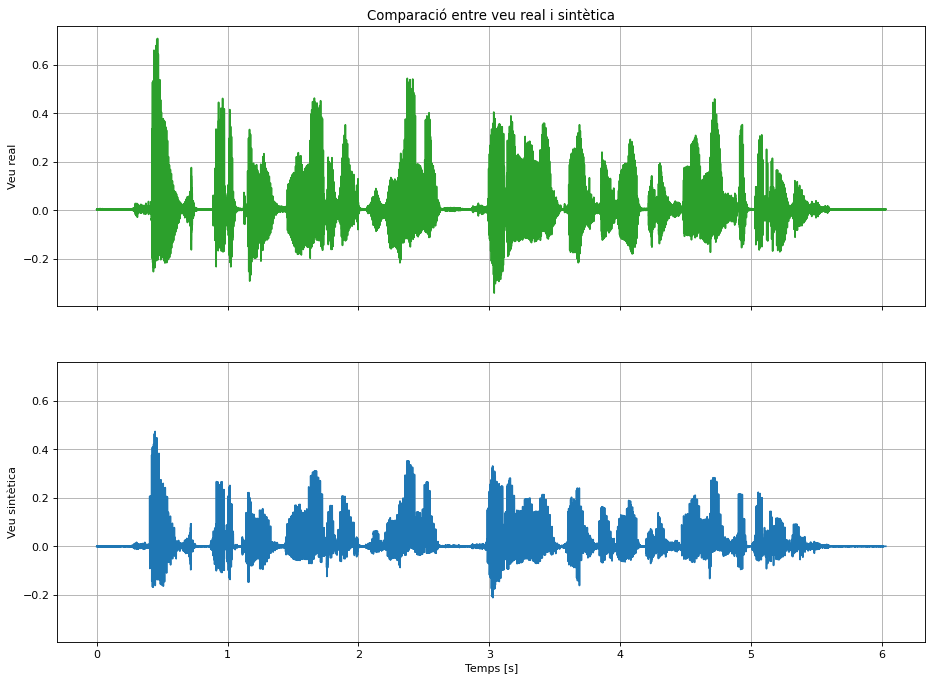

In [169]:
# 5. Presentació i desat de resultats

# Plotting
fig, (ax1, ax2) = plt.subplots(2,1,sharex=True, sharey=True)
t = np.arange(len(veu_original))/fm
ax1.plot(t,veu_original, color='C2')
ax1.grid(True, which='both', axis='both')
ax1.set_title('Comparació entre veu real i sintètica')
ax1.set_ylabel('Veu real')
ax2.plot(t,veu_sintetitzada)
ax2.grid(True, which='both', axis='both')
ax2.set_ylabel('Veu sintètica')
_ = ax2.set_xlabel('Temps [s]')

In [171]:
###### Escoltem la veu dins del Jupyter
veu_sintetitzada = veu_sintetitzada.astype(np.float32)    # <<<< Sembla que és important en sistemes Windows
Audio(veu_sintetitzada,rate=fm, autoplay=False)

In [15]:
# Desat de la veu sintetitzada (OPCIONAL)
# Convertim a int16
veu_sintetitzada = veu_sintetitzada * 2**15
veu_sintetitzada = veu_sintetitzada.astype(np.int16)
wavfile.write(join(cami,nom) + '_sintètica.wav', fm, veu_sintetitzada)

# <span style="color:#BB44DD">Part 6: Millora de l'algorisme.</span>

Si escolteu el vostre primer intent de síntesi de veu i observeu atentament el senyal generat (fent el _zoom_ que calgui), veureu que la qualitat del resultat és millorable:

- S'aprecien discontinuïtats en el senyal de veu
- Hi ha intervals de zeros on no hi hauria d'haver senyal.

Les causes d'això són diverses i per aquest motiu la tècnica de la síntesi de la veu no és bufar i fer ampolles. Però hi ha dues millores senzilles que podeu fer al vostre algorisme, que faran augmentar molt la qualitat del resultat:

1. Cada vegada que genereu un tram de veu fent passar la vostra excitació pel filtre, aquest comença amb unes condicions inicials nul·les i per això la sortida és completament independent de la del tram anterior, cosa que fa que es puguin produir "salts" entre trams i/o zones buides de senyal mentre no arriba la primera "delta" de l'excitació del tram següent. Per tal d'evitar o minimitzar això, hem de fer entrar en joc les __condicions inicials i finals__ del filtre.

    Si consulteu l'ajuda de la funció `lfilter` veureu que accepta com a entrada un paràmetre «`zi`» que són les condicions inicials (també anomenades «estat») a l'inici del càlcul, i retorna un paràmetre «`zf`» que són les condicions (estat) al __final__ del càlcul. <span style="color:red">Així, només cal desar l'estat final de cada tram per tal d'usar-lo com a estat inicial del següent tram</span>. El primer estat de tots serà obviament nul i l'inicialitzarem així:
    
    ```zi = 0*lfilter_zi(b[0], a[0]) #c.i. = 0```

2. Per cada trama sonora generem una excitació consistent en un tren de deltes separades «`sep`» mostres. Però si sempre fem que la primera delta de cada tram estigui a la posició zero, pot passar perfectament que la separació entra l'última delta del tram anterior i la primera del nou tram sigui massa petita/gran, cosa que provocarà una primera resposta massa prop/lluny d'on tocaria i això generarà freqüències que no hi haurien de ser.

    En conseqüència, el tren de deltes del nou tram NO ha de començar a la posició zero sinó que ho ha de fer a la posició `sep-Q`, essent _«Q»_ el nombre de mostres entre la darrera delta i el final del tram anterior.
    
### Per tant, l'objectiu d'aquest apartat és fer les modificacions necessàries al codi de la part 4 per tal de millorar el resultat de la síntesi.

In [175]:
# 6. Introduïu aquí l'algorisme modificat

# Carreguem la llista de coeficients. Té el mateix nom que el fitxer WAV però amb "Coeficients_" davant i extensió «NPZ»
# Construïm el nom del fitxer de coeficients
fitxer_coef = join(cami, "Coeficients_" + nom + '.npz')

# Carreguem amb gestió d'excepcions
with np.load(fitxer_coef) as coef:
    a = coef['a']       # a[k] contindrà els coeficients a1..aP del tram «k»
    b = coef['b']       # b[k] contindrà el coeficient b del tram «k»

## Calculem la finestra una única vegada
FINESTRA = hamming(int(DURADA))

# Inicialitzem variables
L = int(DURADA-SOLAPAMENT)           # Longitud de cada tram de síntesi, en mostres
veu_sintetitzada = []           # Anirem afegint aquí els trams
Q = 0                        # S'UTILITZA A LA PART 6, inicialitzat la variable
zi = 0*lfilter_zi(b[0], a[0]) #c.i. = 0    # Inicialitzat la variable


for num_tram in range(int(P)):
    
    ## Extracció del tram
    inici_tram = int(L*num_tram)  # Igual que a l'apartat 5
    tram = veu_original[inici_tram:inici_tram+DURADA]        # Igual que a l'apartat 5

    ## Restem el (possible) component continu del senyal i l'enfinestrem
    tram = tram - np.mean(tram)
    tram = tram * FINESTRA

    # Calculem paràmetres del tram
    E, sonor, sep = analitza_tram(tram)

    # Generem l'excitació, sorda/sonora segons l'anàlisi, i amb el període adient
    if sonor:
        # protecció contra "sep" massa petits
        if sep < 1:
            sep = 1
        # Creem l'excitació sonora (tren de deltes)
        x = np.zeros(L)                # Modificat: les deltes s'afegeixen començant des de sep-Q fins el final
        x[sep-Q::sep] = np.sqrt(sep)
        Q = L - np.max(np.nonzero(x)) - 1
    else:
        # Creem l'excitació sorda (soroll)
        x = np.random.normal(size=L)    # Igual que a l'apartat 5
    # Filtrem l'excitació amb el filtre indicat pels coeficients
    y, zi = lfilter(b[num_tram], a[num_tram], x, zi = zi)   # Modificat: afegit les condicions inicials
    veu_sintetitzada.append(y)


    
# Afegiu al final els zeros necessaris per igualar les longituds de les veus original i sintètica i així poder-les representar conjuntament
veu_sintetitzada.append([0 for _ in range(int(SOLAPAMENT))])  # Igual que a l'apartat 5

# Concatenem tots els trams de la llista en un únic array NumPy
veu_sintetitzada = np.concatenate(veu_sintetitzada)



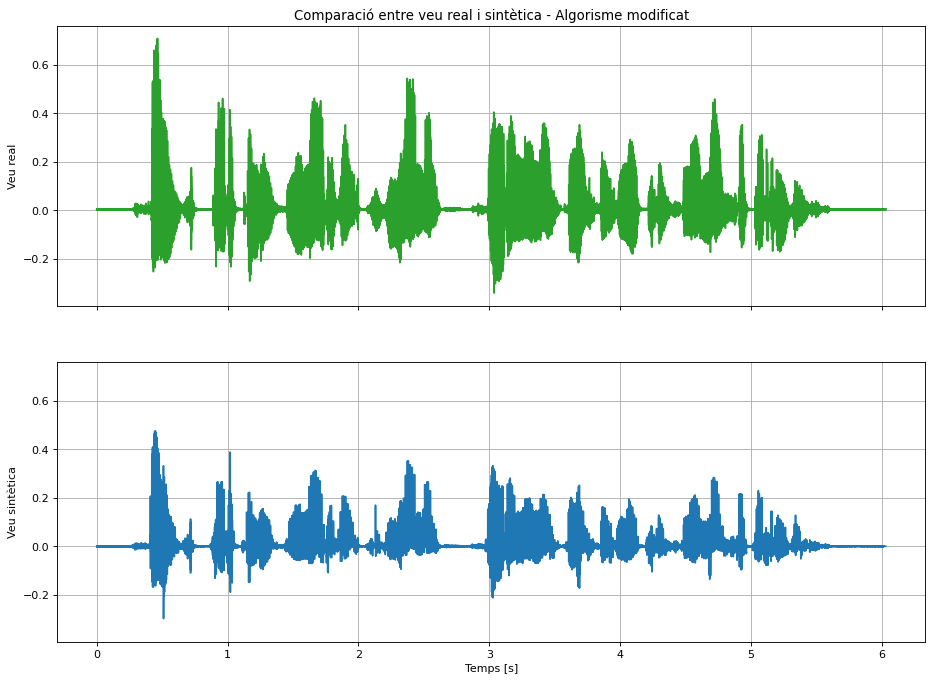

In [177]:
# Presentació de resultats

# Plotting
fig, (ax1, ax2) = plt.subplots(2,1,sharex=True, sharey=True)
t = np.arange(len(veu_original))/fm
ax1.plot(t,veu_original, color='C2')
ax1.grid(True, which='both', axis='both')
ax1.set_title('Comparació entre veu real i sintètica - Algorisme modificat')
ax1.set_ylabel('Veu real')
ax2.plot(t,veu_sintetitzada)
ax2.grid(True, which='both', axis='both')
ax2.set_ylabel('Veu sintètica')
_ = ax2.set_xlabel('Temps [s]')

# Escoltem la veu dins del Jupyter
veu_sintetitzada = veu_sintetitzada.astype(np.float32)    # <<<< Sembla que és important en sistemes Windows
Audio(veu_sintetitzada,rate=fm, autoplay=False)

# <span style="color:#BB44DD">Part 7: (OPCIONAL) Modificacions al senyal sintètic.</span>

Com que tenim accés total als paràmetres de síntesi de la veu, podem jugar a variar-ne alguns per tal d'obtenir un senyal sintètic diferent a l'original. Alguns suggeriments que us fem són:

* Podeu «escurçar» o «allargar» la veu modificant la longitud de les trames de síntesi. En aquest cas la veu sintètica tindrà una longitud inferior o superior a la veu original, per la qual cosa haureu d'afegir zeros on correspongui i també recalcular el vector de temps associat, per tal que el codi que genera les gràfiques no es queixi.
* Podeu modificar el període fonamental de cada trama (variable `sep`), per exemple incrementant-lo o decrementant-lo un 20% (i passant-lo a enter) __o ser molt més creatius__.
* Podeu considerar tots els trams sords o sonors (en aquest cas mantenint la variable `sep` del tram anterior).
* També podeu comprovar si teniu el vostre programa adequadament parametritzat, executant el vostre algorisme amb un fitxer WAV diferent (per exemple: "Aloma.wav")
* Finalment podríeu gravar un fragment de la __vostra pròpia veu__ i aplicar-li l'algorisme. Per fer-ho podeu usar el programa "Audacity" (<span style="color:red">parleu amb el professor per tal que us doni indicacions detallades</span>) però el procediment consisteix bàsicament en:
    * Gravar el senyal
    * Si és estèreo, mesclar els dos canals a una única pista monofònica
    * Baixar la freqüència de mostratge a 8 kHz
    * Exportar i desar el senyal a un fitxer WAV en format 16 bits amb signe
    * Generar el fitxer amb els coeficients dels filtres calculats per cada tram __del vostre senyal__. Aquesta part resta ara per ara fora dels objectius docents. Parleu-ne amb el professor
    * Aplicar el codi que heu creat a la vostra veu

Per cada provatura sintetitzeu el senyal i escolteu el resultat.

__NOTA:__ Si voleu fer aquesta part __no modifiqueu el codi que ja funciona__ (i que heu d'entregar), sinó que copieu al dessota el codi de la part 4 i modifiqueu-lo a banda. Si ho desitgeu i considereu que heu trobat algun efecte interessant podeu generar també la gràfica i incloure el reproductor d'Àudio pel nou senyal.

In [ ]:
# (OPCIONAL) Copieu el codi de la part 4 i modifiqueu-lo al vostre gust


In [ ]:
# (OPCIONAL) Plotting
#fig, (ax1, ax2) = plt.subplots(2,1,sharex=True, sharey=True)
#t = np.arange(len(veu_original))/fm
#ax1.plot(t,veu_original, color='C2')
#ax1.grid(True, which='both', axis='both')
#ax1.set_title('Comparació entre veu real i sintètica')
#ax1.set_ylabel('Veu real')
#ax2.plot(t,veu_sintetitzada)
#ax2.grid(True, which='both', axis='both')
#ax2.set_ylabel('Veu sintètica')
#_ = ax2.set_xlabel('Temps [s]')

In [ ]:
# (OPCIONAL) Escoltem la veu dins del Jupyter
#veu_sintetitzada = veu_sintetitzada.astype(np.float32)    # <<<< Sembla que és important en sistemes Windows
#Audio(veu_sintetitzada,rate=fm, autoplay=False)

# <span style="color:#BB44DD">Part 8: Entrega de resultats.</span>

L'entrega de resultats d'aquesta activitat de laboratori consisteix en aquest mateix «notebook», el qual convertireu prèviament a format HTML seguint els passos següents:

1. A la línia 8 del primer bloc de codi, canvieu `%matplotlib qt` per `%matplotlib inline`.
2. Reinicieu el _kernel_ i executeu tot el full de dalt a baix amb el símbol de la doble fletxa «⏩», comprovant que no teniu cap error al codi.
3. Aneu al menú "file" i __exporteu__ el notebook en format __HTML__.
4. Obriu el fitxer HTML resultant amb un navegador qualsevol i comproveu que les gràfiques es veuen, que l'àudio se sent i que el codi és el que voleu entregar.
5. Pugeu el fitxer HTML a la tasca d'ATENEA corresponent. __Entregueu únicament un fitxer per grup de treball__.

----

<h1 align="center">Final de l'enunciat<h1/>

----